# Практические занятия Листок 3. Кривые, траектории и механические системы


In [34]:
import math
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.integrate import solve_ivp
from scipy.special import ellipk
from sympy import *
import sympy as sp

init_printing()
g = 9.81

### **3.1** Найдите кривую в вертикальной плоскости, по которой тяжёлая точка под действием силы тяжести опускается с постоянной вертикальной скоростью. Получите уравнение кривой и постройте графики для различных начальных условий.

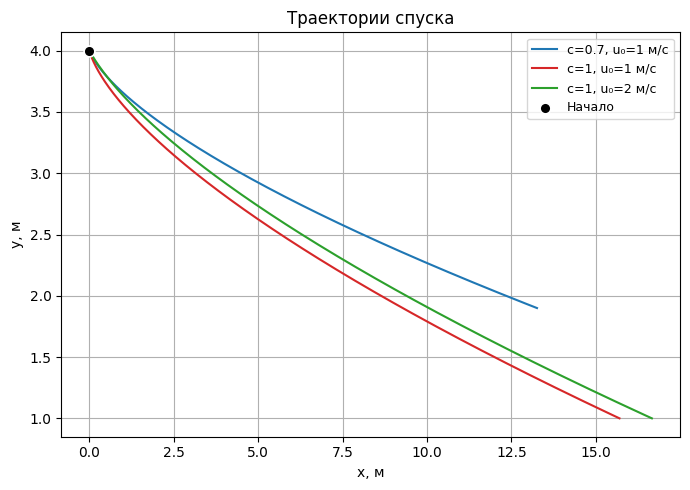

In [35]:
t = np.linspace(0, 3, 300)
x0, y0 = 0, 4
colors = ["#1f77b4", "#d62728", "#2ca02c"]

fig, ax = plt.subplots()
for (c, u0), color in zip([(0.7, 1), (1, 1), (1, 2)], colors):
    x = x0 + ((u0 ** 2 + 2 * g * c * t) ** 1.5 - u0 ** 3) / (3 * g * c)
    y = y0 - c * t
    label = f"c={c:g}, u₀={u0:g} м/с"
    ax.plot(x, y, color=color, label=label)

ax.scatter([x0], [y0], color="black", s=60, zorder=5, edgecolor="white", linewidth=1.2, label="Начало")
ax.set_title("Траектории спуска")
ax.set_xlabel("x, м")
ax.set_ylabel("y, м")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

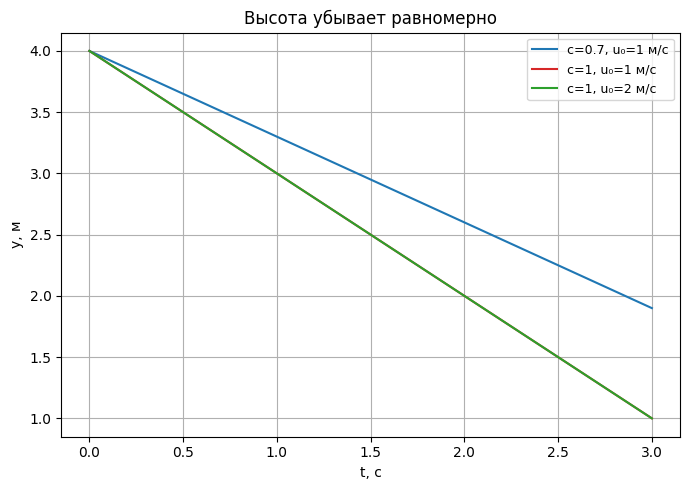

In [36]:
colors = ["#1f77b4", "#d62728", "#2ca02c"]

fig, ax = plt.subplots()
for (c, u0), color in zip([(0.7, 1), (1, 1), (1, 2)], colors):
    y = y0 - c * t
    label = f"c={c:g}, u₀={u0:g} м/с"
    ax.plot(t, y, color=color, label=label)

ax.set_title("Высота убывает равномерно")
ax.set_xlabel("t, с")
ax.set_ylabel("y, м")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### **3.2** Исследуйте движение бильярдного шара в прямоугольнике с упругими отражениями от стенок. Объясните метод развёртки, условия периодичности и постройте примеры траекторий.

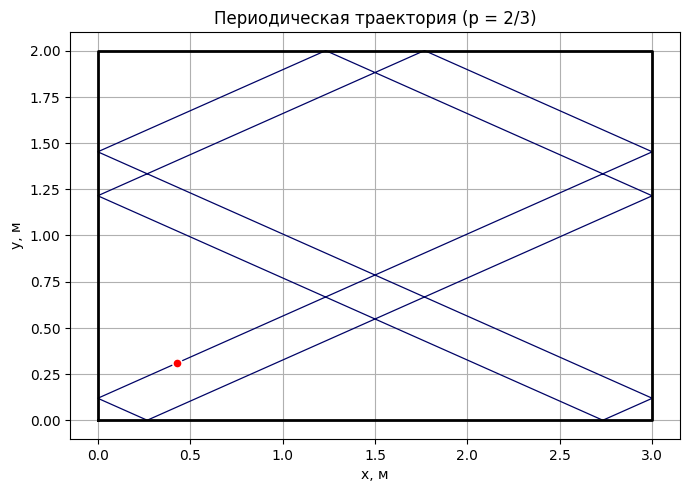

In [37]:
a, b = 3, 2
x0, y0, vx = 0.43, 0.31, 1

def reflect(s, length):
    return length - np.abs(s % (2 * length) - length)

# Периодическая траектория (p = 2/3)
rho = 2 / 3
vy = b * vx * rho / a
t = np.linspace(0, 18, 6000)
X, Y = x0 + vx * t, y0 + vy * t

fig, ax = plt.subplots()
ax.plot(reflect(X, a), reflect(Y, b), lw=0.9, color="#000366")
ax.plot([0, a, a, 0, 0], [0, 0, b, b, 0], color="black", lw=2)
ax.scatter([x0], [y0], color="red", s=45, zorder=5, edgecolor="white", linewidth=1.2)
ax.set_title("Периодическая траектория (p = 2/3)")
ax.set_xlabel("x, м")
ax.set_ylabel("y, м")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

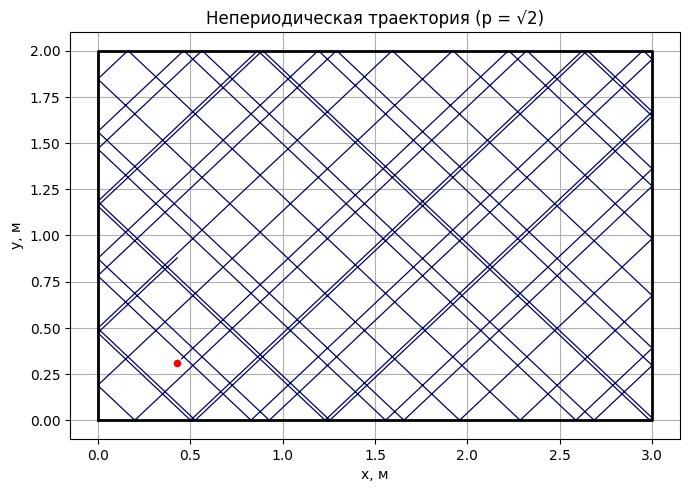

In [38]:
# Непериодическая траектория (p = √2)
rho = np.sqrt(2)
vy = b * vx * rho / a
t = np.linspace(0, 60, 6000)
X, Y = x0 + vx * t, y0 + vy * t

fig, ax = plt.subplots()
ax.plot(reflect(X, a), reflect(Y, b), lw=0.9, color="#000366")
ax.plot([0, a, a, 0, 0], [0, 0, b, b, 0], color="black", lw=2)
ax.scatter([x0], [y0], color="red", s=45, zorder=5, edgecolor="white", linewidth=1.2)
ax.set_title("Непериодическая траектория (p = √2)")
ax.set_xlabel("x, м")
ax.set_ylabel("y, м")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

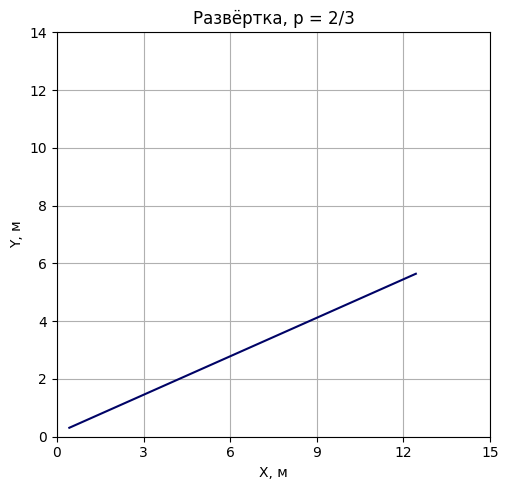

Для p=2/3 период T = 2 * a * 3 / vx = 18 с.


In [39]:
# Развёртка для периодической траектории (p = 2/3)
rho = 2 / 3
vy = b * vx * rho / a
t = np.linspace(0, 18, 6000)
X, Y = x0 + vx * t, y0 + vy * t

fig, ax = plt.subplots()
part = t <= 12
ax.plot(X[part], Y[part], color="#000366")
ax.set_title("Развёртка, p = 2/3")
ax.set_xlabel("X, м")
ax.set_ylabel("Y, м")
ax.set_xlim(0, 15)
ax.set_ylim(0, 14)
ax.set_aspect("equal")
ax.set_xticks(np.arange(0, 16, a))
ax.set_yticks(np.arange(0, 15, b))
plt.tight_layout()
plt.show()

print(f"Для p=2/3 период T = 2 * a * 3 / vx = {2 * a * 3 / vx:g} с.")

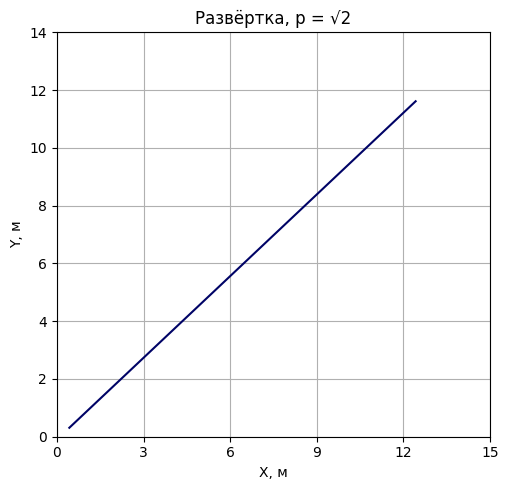

In [40]:
# Развёртка для непериодической траектории (p = √2)
rho = np.sqrt(2)
vy = b * vx * rho / a
t = np.linspace(0, 60, 6000)
X, Y = x0 + vx * t, y0 + vy * t

fig, ax = plt.subplots()
part = t <= 12
ax.plot(X[part], Y[part], color="#000366")
ax.set_title("Развёртка, p = √2")
ax.set_xlabel("X, м")
ax.set_ylabel("Y, м")
ax.set_xlim(0, 15)
ax.set_ylim(0, 14)
ax.set_aspect("equal")
ax.set_xticks(np.arange(0, 16, a))
ax.set_yticks(np.arange(0, 15, b))
plt.tight_layout()
plt.show()

### **3.3** Найдите форму равновесия однородной тяжёлой нерастяжимой цепи, подвешенной за два конца. Получите уравнение цепной линии, объясните смысл параметра a и постройте графики.

**Параметры цепной линии:**

| a, м | Длина L, м | Провисание f, м |
|:----:|:----------:|:---------------:|
| 1 | 7.254 | 2.762 |
| 1.6 | 5.126 | 1.421 |
| 3 | 4.303 | 0.692 |


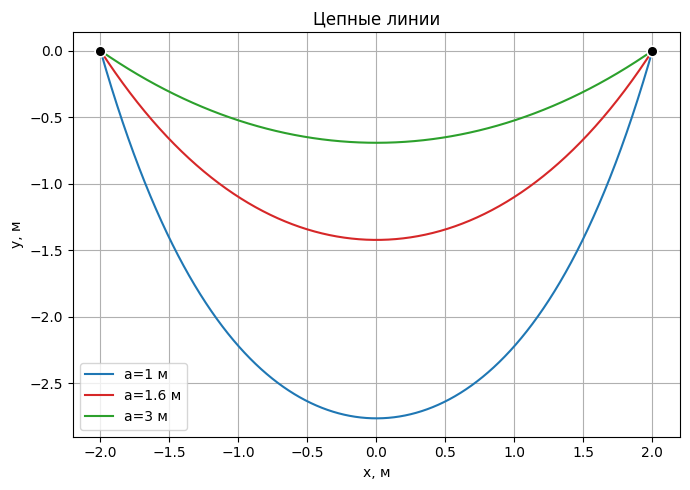

In [41]:
d, mu = 2, 1
x = np.linspace(-d, d, 300)
colors = ["#1f77b4", "#d62728", "#2ca02c"]
a_values = [1, 1.6, 3]

rows = []
for a in a_values:
    length = 2 * a * np.sinh(d / a)
    sag = a * (np.cosh(d / a) - 1)
    rows.append((a, length, sag))
table = "| a, м | Длина L, м | Провисание f, м |\n"
table += "|:----:|:----------:|:---------------:|\n"
for a, L, f in rows:
    table += f"| {a:g} | {L:.3f} | {f:.3f} |\n"
display(Markdown("**Параметры цепной линии:**"))
display(Markdown(table))
fig, ax = plt.subplots()
for a, color in zip(a_values, colors):
    y = a * (np.cosh(x / a) - np.cosh(d / a))
    ax.plot(x, y, color=color, label=f"a={a:g} м")

ax.scatter([-d, d], [0, 0], color="black", s=60, zorder=5, edgecolor="white", linewidth=1.2)
ax.set_title("Цепные линии")
ax.set_xlabel("x, м")
ax.set_ylabel("y, м")
ax.legend()
plt.tight_layout()
plt.show()

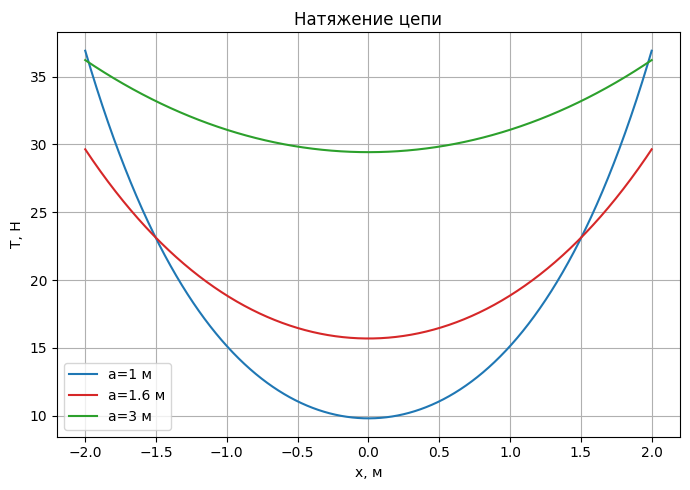

In [42]:
fig, ax = plt.subplots()
for a, color in zip([1, 1.6, 3], colors):
    tension = mu * g * a * np.cosh(x / a)
    ax.plot(x, tension, color=color, label=f"a={a:g} м")

ax.set_title("Натяжение цепи")
ax.set_xlabel("x, м")
ax.set_ylabel("T, Н")
ax.legend()
plt.tight_layout()
plt.show()

### **3.4** Найдите кривую, по которой время спуска материальной точки под действием тяжести до нижней точки не зависит от начального положения. Получите уравнение кривой и покажите спуск с разных высот на графике.

При R=1 м время спуска со всех высот T=1.003033 с.


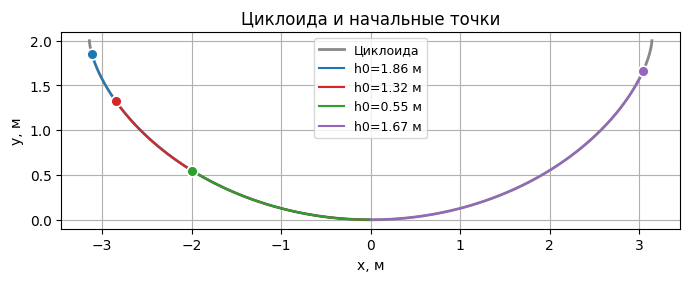

In [43]:
R = 1
T = np.pi * np.sqrt(R / g)
omega = np.sqrt(g / (4 * R))
t = np.linspace(0, T, 300)
theta = np.linspace(-np.pi, np.pi, 400)
colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]

fig, ax = plt.subplots()
ax.plot(R * (theta + np.sin(theta)), R * (1 - np.cos(theta)), color="#888888", lw=2, label="Циклоида")

for theta0, color in zip([-2.6, -1.9, -1.1, 2.3], colors):
    s0 = 4 * R * np.sin(theta0 / 2)
    s = s0 * np.cos(omega * t)
    angle = 2 * np.arcsin(s / (4 * R))
    x = R * (angle + np.sin(angle))
    y = R * (1 - np.cos(angle))
    label = f"h0={y[0]:.2f} м"
    ax.plot(x, y, color=color, label=label)
    ax.scatter([x[0]], [y[0]], s=60, color=color, zorder=5, edgecolor="white", linewidth=1.2)

print(f"При R={R} м время спуска со всех высот T={T:.6f} с.")
ax.set_title("Циклоида и начальные точки")
ax.set_xlabel("x, м")
ax.set_ylabel("y, м")
ax.set_aspect("equal")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

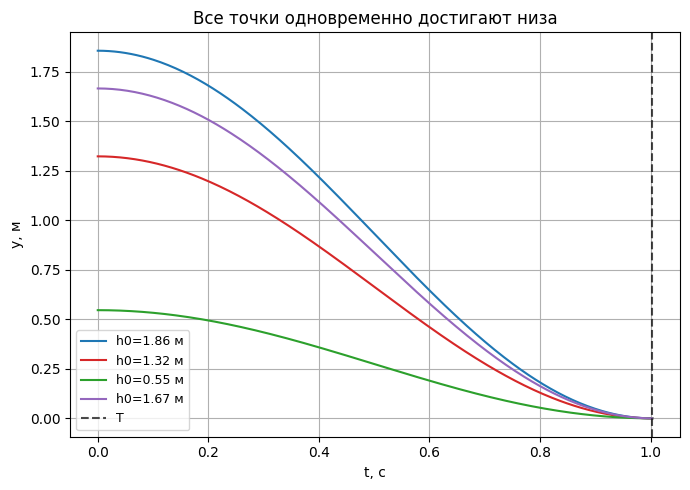

In [44]:
fig, ax = plt.subplots()
for theta0, color in zip([-2.6, -1.9, -1.1, 2.3], colors):
    s0 = 4 * R * np.sin(theta0 / 2)
    s = s0 * np.cos(omega * t)
    angle = 2 * np.arcsin(s / (4 * R))
    y = R * (1 - np.cos(angle))
    label = f"h0={y[0]:.2f} м"
    ax.plot(t, y, color=color, label=label)

ax.axvline(T, color="black", ls="--", lw=1.5, alpha=0.7, label="T")
ax.set_title("Все точки одновременно достигают низа")
ax.set_xlabel("t, с")
ax.set_ylabel("y, м")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### **3.5** Исследуйте движение математического маятника — точечной массы на невесомом нерастяжимом стержне. Сравните малые и большие колебания, постройте фазовый портрет и зависимость периода от амплитуды.

Период малых колебаний: 2.006067 с.
Амплитуда 10 градусов, а период 2.009893 с.
Амплитуда 120 градусов, а период 2.754090 с.


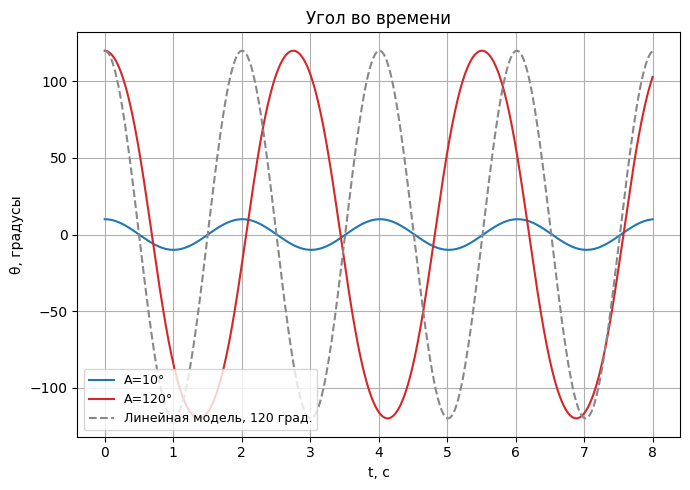

In [45]:
t = np.linspace(0, 8, 600)
l = 1
def equation(t, state):
    theta, speed = state
    return [speed, -g / l * np.sin(theta)]

fig, ax = plt.subplots()
print(f"Период малых колебаний: {2 * np.pi * np.sqrt(l / g):.6f} с.")
for degrees, color in zip([10, 120], ["#1f77b4", "#d62728"]):
    A = np.deg2rad(degrees)
    solution = solve_ivp(equation, (0, 8), [A, 0], t_eval=t, rtol=1e-8, atol=1e-10)
    ax.plot(t, np.rad2deg(solution.y[0]), color=color, label=f"A={degrees}°")
    period = 4 * np.sqrt(l / g) * ellipk(np.sin(A / 2) ** 2)
    print(f"Амплитуда {degrees} градусов, а период {period:.6f} с.")

ax.plot(t, 120 * np.cos(np.sqrt(g / l) * t), "--", color="#888888", lw=1.5, label="Линейная модель, 120 град.")
ax.set_title("Угол во времени")
ax.set_xlabel("t, с")
ax.set_ylabel("θ, градусы")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

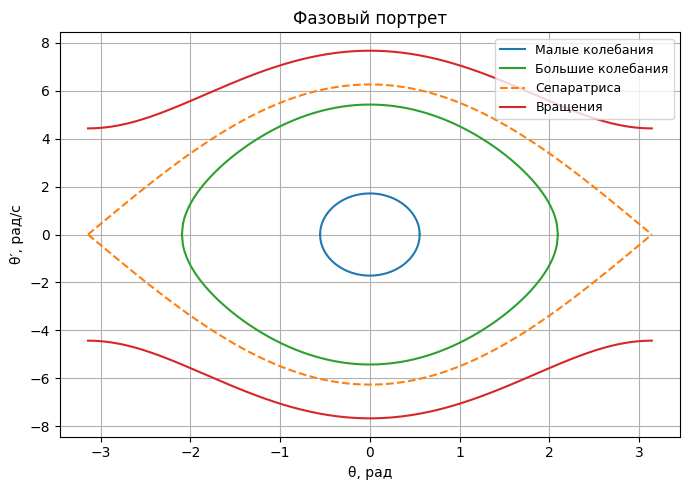

In [46]:
fig, ax = plt.subplots()
energy_styles = [
    (0.15, "Малые колебания", "#1f77b4", "-"),
    (1.5, "Большие колебания", "#2ca02c", "-"),
    (2, "Сепаратриса", "#ff7f0e", "--"),
    (3, "Вращения", "#d62728", "-"),
]
for energy, label, color, ls in energy_styles: # ЗСЭ
    # При колебаниях угол ограничен положениями, где скорость ноль
    limit = np.arccos(1 - energy) if energy < 2 else np.pi
    angle = np.linspace(-limit, limit, 400)
    # E/(mgl)
    speed2 = 2 * g / l * (energy - 1 + np.cos(angle))  
    speed = np.sqrt(np.maximum(speed2, 0))
    ax.plot(angle, speed, ls, color=color, label=label)
    ax.plot(angle, -speed, ls, color=color)

ax.set_title("Фазовый портрет")
ax.set_xlabel("θ, рад")
ax.set_ylabel("θ′, рад/с")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

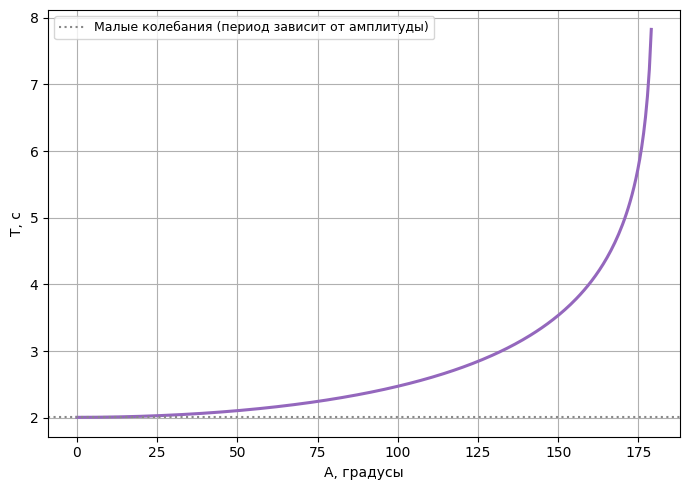

In [47]:
fig, ax = plt.subplots()
amplitudes = np.linspace(0, 179, 300)
periods = 4 * np.sqrt(l / g) * ellipk(np.sin(np.deg2rad(amplitudes) / 2) ** 2)
ax.plot(amplitudes, periods, color="#9467bd", lw=2.2)
ax.axhline(2 * np.pi * np.sqrt(l / g), color="#888888", ls=":", lw=1.5, label="Малые колебания (период зависит от амплитуды)")
ax.set_xlabel("A, градусы")
ax.set_ylabel("T, с")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()